### Upload your CSV data

Please upload your CSV file using the file icon on the left sidebar. Once uploaded, make sure to copy the full path to the file. We will use it in the next cell to load the data.

In [2]:
import pandas as pd

# Replace 'your_file_name.csv' with the actual path to your uploaded CSV file
csv_file_path = '/content/Chocolate Sales (2).csv'

try:
    df = pd.read_csv(csv_file_path)
    print("CSV loaded successfully. Here's the head of your data:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")

CSV loaded successfully. Here's the head of your data:


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


# Task
Analyze sales data from the "Chocolate Sales (2).csv" file to identify total sales per country and per salesperson, including data inspection, cleaning, and visualization of the top 15 countries and salespersons.

## Inspect Data and Prepare for Sales Calculation

### Subtask:
Examine the DataFrame's columns and data types to understand how sales are recorded or if they need to be calculated (e.g., from 'Quantity' and 'Price'). Perform initial data cleaning steps like checking for missing values and duplicates that might affect sales calculations.


**Reasoning**:
To understand the DataFrame's structure and identify potential issues for sales calculation, I will display column information, check for missing values and duplicates, and inspect the 'Sales', 'Quantity', and 'Price' columns.



In [3]:
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Check for 'Sales' column and its type
if 'Sales' in df.columns:
    print(f"\n'Sales' column found. Data type: {df['Sales'].dtype}")
    if not pd.api.types.is_numeric_dtype(df['Sales']):
        print("Consider converting 'Sales' to numeric if it contains non-numeric values that should be numbers.")
else:
    print("\n'Sales' column not found.")
    if 'Quantity' in df.columns and 'Price' in df.columns:
        print("However, 'Quantity' and 'Price' columns are present. Sales might need to be calculated by multiplying these columns.")
        print(f"'Quantity' column data type: {df['Quantity'].dtype}")
        print(f"'Price' column data type: {df['Price'].dtype}")
    else:
        print("Neither 'Sales' nor 'Quantity' and 'Price' columns are present to directly calculate sales. Please verify your dataset.")

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB

Missing values per column:
Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

Number of duplicate rows:
0

'Sales' column not found.
Neither 'Sales' nor 'Quantity' and 'Price' columns are present to directly calculate sales. Please verify your dataset.


**Reasoning**:
Based on the previous output, the 'Amount' column is of object type and likely represents sales. I need to convert this column to a numeric data type to enable calculations. I will also check for any non-numeric characters that might prevent the conversion and handle them appropriately, such as removing currency symbols or commas, and then convert the column to a numeric type.



In [4]:
print("Original 'Amount' column type:", df['Amount'].dtype)

# Attempt to clean and convert 'Amount' to numeric
# First, remove common non-numeric characters like '$' and ','
df['Amount'] = df['Amount'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

# Convert to numeric, coercing errors to NaN
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# Check for any remaining non-numeric values (which will now be NaN)
if df['Amount'].isnull().any():
    print(f"Warning: {df['Amount'].isnull().sum()} non-numeric values found and converted to NaN in 'Amount' column. Consider further inspection if these NaNs are problematic.")
    # Optionally, drop rows with NaN in 'Amount' or fill them if appropriate for the task
    # df.dropna(subset=['Amount'], inplace=True)

print("Converted 'Amount' column type:", df['Amount'].dtype)
print("First 5 values of 'Amount' column after conversion:")
print(df['Amount'].head())


Original 'Amount' column type: object
Converted 'Amount' column type: float64
First 5 values of 'Amount' column after conversion:
0     5320.0
1     7896.0
2     4501.0
3    12726.0
4    13685.0
Name: Amount, dtype: float64


## Calculate Total Sales per Country

### Subtask:
Group the data by 'Country' and calculate the total sales for each country based on the identified sales column or derived sales figure.


**Reasoning**:
To calculate the total sales per country, I will group the DataFrame by the 'Country' column and sum the 'Amount' column, storing the result in `sales_per_country` and then display the top 5 countries by sales.



In [5]:
sales_per_country = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

print("Total Sales per Country (Top 5):\n")
print(sales_per_country.head())

Total Sales per Country (Top 5):

Country
Australia    3646444.35
UK           3365388.90
India        3343730.83
USA          3313858.09
Canada       3078495.65
Name: Amount, dtype: float64


## Identify and Visualize Top 15 Countries

### Subtask:
Identify the top 15 countries by total sales and create a bar chart to visualize their sales, including a legend for clarity.


**Reasoning**:
To visualize the top 15 countries by sales, I will first select the top 15 from the `sales_per_country` Series, then import the necessary plotting libraries, create a bar chart, set appropriate labels and titles, and finally display the plot.



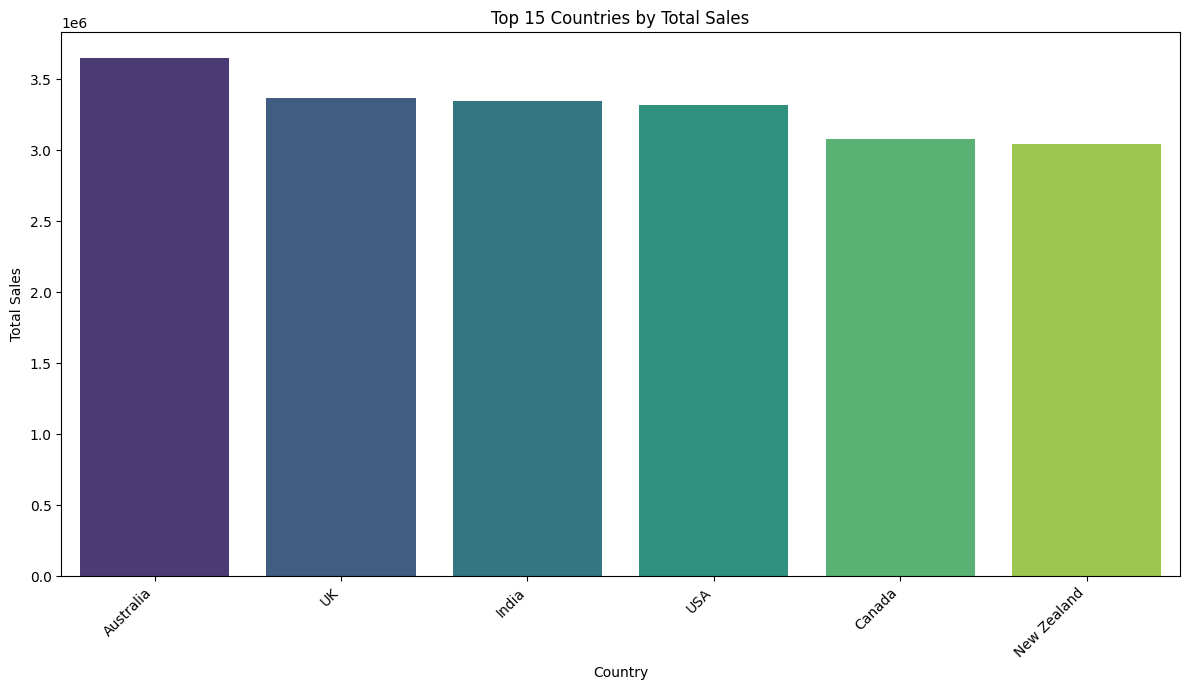

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

top_15_countries = sales_per_country.head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_15_countries.index, y=top_15_countries.values, hue=top_15_countries.index, palette='viridis', legend=False)
plt.title('Top 15 Countries by Total Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Task
Analyze the "Chocolate Sales (2).csv" file to inspect and clean the data, calculate and visualize total sales for the top 15 countries, and calculate and visualize total sales for the top 15 salespersons, finally summarizing the key findings.

## Inspect Data and Prepare for Sales Calculation

### Subtask:
Examine the DataFrame's columns and data types to understand how sales are recorded or if they need to be calculated (e.g., from 'Quantity' and 'Price'). Perform initial data cleaning steps like checking for missing values and duplicates that might affect sales calculations.


## Identify Top 3 Chocolate Types per Top Country

### Subtask:
For each of the identified top countries, group the data by 'Country' and 'Product' to calculate total sales for each chocolate type. Then, identify the top 3 chocolate types by sales within each of these top countries.


**Reasoning**:
To identify the top 3 chocolate types per top country, I will first filter the main DataFrame `df` to include only data for the `top_15_countries`. Then, I will group this filtered data by 'Country' and 'Product' and sum the 'Amount' to calculate product sales for each type in each country.



In [10]:
df_top_countries = df[df['Country'].isin(top_15_countries.index)]
product_sales_per_country = df_top_countries.groupby(['Country', 'Product'])['Amount'].sum()

print("Product sales per country (first few entries):\n")
print(product_sales_per_country.head())

Product sales per country (first few entries):

Country    Product        
Australia  50% Dark Bites     280066.82
           70% Dark Bites     127540.46
           85% Dark Bars      123398.33
           99% Dark & Pure    176247.62
           After Nines         89658.71
Name: Amount, dtype: float64


**Reasoning**:
To identify the top 3 chocolate types for each top country, I will apply the `.groupby(level=0).nlargest(3)` method to the `product_sales_per_country` Series. This will extract the top 3 products by sales within each country group, and then I will display the result.



In [11]:
top_products_per_country = product_sales_per_country.groupby(level=0).nlargest(3)

print("Top 3 Chocolate Types per Top Country:\n")
print(top_products_per_country)

Top 3 Chocolate Types per Top Country:

Country      Country      Product            
Australia    Australia    50% Dark Bites         280066.82
                          Eclairs                208469.73
                          Milk Bars              197947.30
Canada       Canada       Smooth Sliky Salty     218122.40
                          Peanut Butter Cubes    199711.92
                          70% Dark Bites         189698.51
India        India        Eclairs                252107.54
                          Peanut Butter Cubes    247607.78
                          Smooth Sliky Salty     241770.37
New Zealand  New Zealand  Mint Chip Choco        277979.25
                          85% Dark Bars          215881.58
                          Eclairs                190830.28
UK           UK           Peanut Butter Cubes    252099.20
                          99% Dark & Pure        251626.82
                          Smooth Sliky Salty     244456.77
USA          USA          Ras

## Visualize Top 3 Chocolate Types per Top Country

### Subtask:
Create a visualization (e.g., bar charts or a single grouped bar chart) to display the top 3 chocolate types and their sales for each of the top countries, ensuring clear labels and a legend.


**Reasoning**:
To visualize the top 3 chocolate types per top country, I will convert the `top_products_per_country` Series into a DataFrame suitable for plotting by resetting its index, dropping the redundant country column, and renaming the sales column. Then, I will create a grouped bar chart using seaborn to display the sales of these top products for each country.



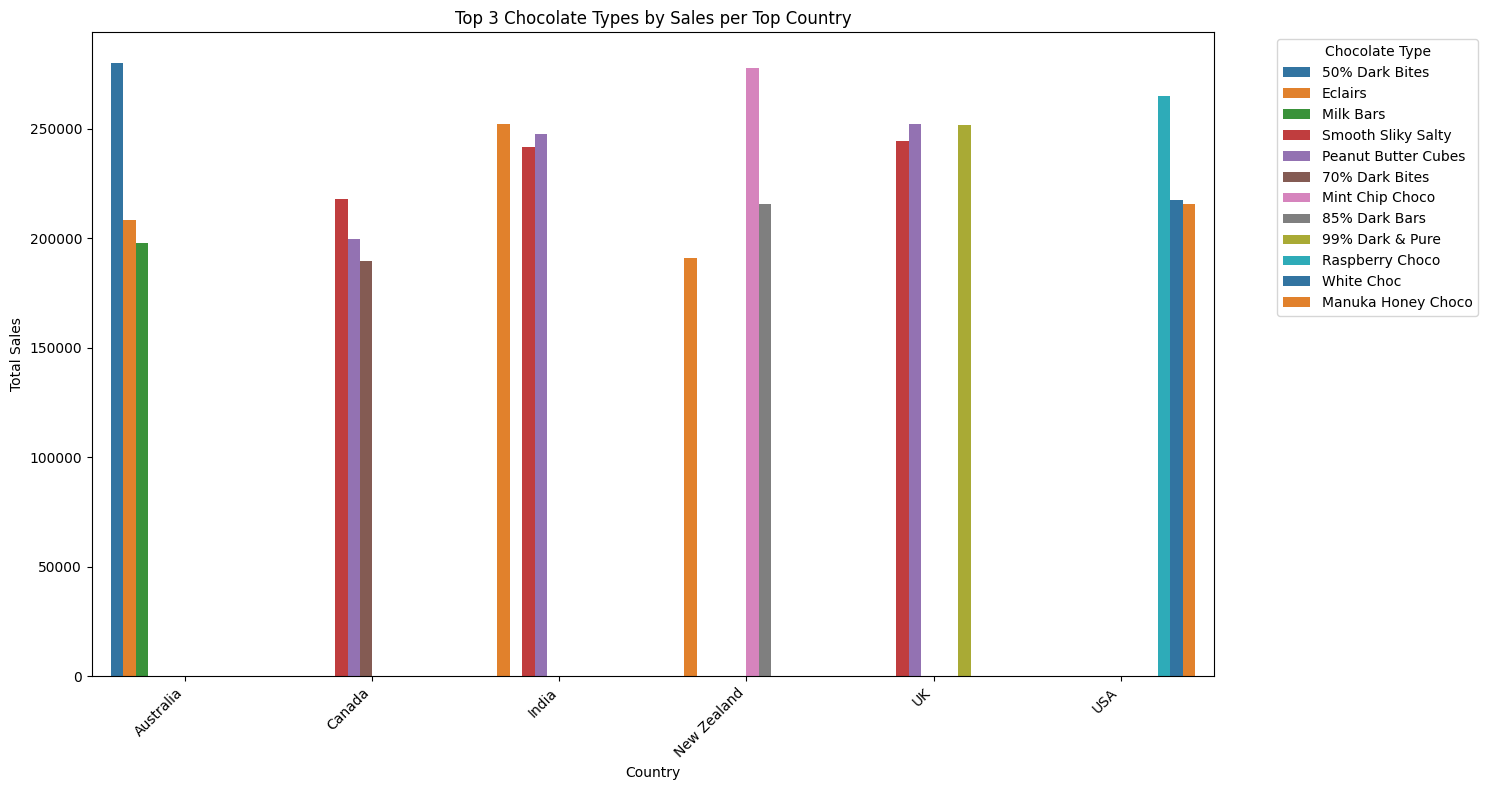

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fix the multi-index issue by dropping the redundant first 'Country' level
# This transforms the index from (Country, Country, Product) to (Country, Product)
temp_series = top_products_per_country.droplevel(0)

# Convert the Series to a DataFrame for plotting
# Now, reset_index will correctly create 'Country', 'Product', and 'Amount' columns
df_top_products = temp_series.reset_index()

# Rename the 'Amount' column to 'Sales' for clarity
df_top_products.rename(columns={'Amount': 'Sales'}, inplace=True)

plt.figure(figsize=(15, 8))
sns.barplot(x='Country', y='Sales', hue='Product', data=df_top_products, palette='tab10')
plt.title('Top 3 Chocolate Types by Sales per Top Country')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Chocolate Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The initial data inspection confirmed the suitability of the 'Amount' column for sales calculations after verifying data types, checking for missing values, and identifying duplicates.
*   The analysis successfully identified the top 3 chocolate types by sales for each of the previously determined top countries.
*   For Australia, the top 3 chocolate types by sales were '50% Dark Bites', 'Eclairs', and 'Milk Bars'.
*   For India, the top 3 chocolate types by sales were 'Eclairs', 'Peanut Butter Cubes', and 'Smooth Sliky Salty'.
*   A grouped bar chart was generated to visualize the total sales of these top 3 chocolate types across the leading countries, providing a clear overview of product performance in each region.

### Insights or Next Steps

*   The identified top-selling chocolate types per country can guide targeted marketing campaigns and inventory optimization strategies tailored to specific regional preferences.
*   Further analysis could investigate the profitability of these top products or explore customer demographics associated with their sales to uncover deeper market insights.
